In [18]:
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

import pandas as pd

import re

In [19]:
#load in crossed Data set
df3 = pd.read_csv("/home/wenyuantong/Desktop/data/all_cross/50_99.csv", index_col=0)
df3.head()

,HopX1a_N-terminal_1_88,HopX1a_C-terminal_298_380,HopX1c_N-terminal_1_87,HopX1c_Middle_212_267,HopX1b_N-terminal_1_74,HopX1g_N-terminal_1_68,HopBO1c_N-terminal_1_57,HopBO1c_Middle_112_205,HopBO1b_N-terminal_1_59,HopBO1b_Middle_105_171,...,Q944Q0_middle_280_334,Q944Q0_middle_425_509,Q94AU3_N-terminal_1_65,Q9ATB4_middle_181_246,Q9ATB4_middle_365_416,Q9C6K4_N-terminal_1_82,Q9C6K4_middle_209_305,Q9C9I4_N-terminal_1_56,Q9LF48_C-terminal_101_175,Q9LXF4_N-terminal_1_79
HopX1a_N-terminal_1_88,3.516703,3.409540,3.072912,0.527976,3.034622,2.831076,2.075563,1.840887,2.084241,1.373931,...,1.775923,1.255023,1.268221,1.336127,0.825495,1.618738,0.813058,1.874163,5.366706,2.702283
HopX1a_C-terminal_298_380,3.614934,3.070338,3.133250,0.394827,3.060764,2.543756,2.101262,1.292691,2.233731,1.243716,...,1.688731,1.362504,1.521192,1.243997,0.938525,1.741289,0.784720,1.152420,5.394567,2.956477
HopX1c_N-terminal_1_87,3.108233,2.989193,2.715768,0.178095,2.704708,2.539902,1.795120,1.351725,1.776713,1.001231,...,1.451790,0.712826,0.903910,0.908437,0.513998,1.100584,0.111875,1.569019,4.963816,2.243116
HopX1c_Middle_212_267,0.829676,0.585189,0.276683,2.636544,0.187466,1.597532,0.544271,3.667013,0.561779,0.975897,...,2.056686,2.902367,-2.632039,1.561512,0.118954,0.793149,3.275426,6.833592,-1.223650,0.353522
HopX1b_N-terminal_1_74,3.608739,3.433020,3.179860,0.141867,3.130227,2.781789,2.099485,1.418330,2.093578,1.249201,...,1.587612,0.859712,1.606587,1.037678,0.746984,1.435214,0.277455,1.082236,5.672187,2.762363


In [20]:
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
	
# Set such that PDF fonts export in a manner that they
# are editable in illustrator/affinity
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# set to define axes linewidths
matplotlib.rcParams['axes.linewidth'] = 0.5

# this defines some prefactors so inline figures look nice
%matplotlib inline
%config InlineBackend.figure_format='retina'


matplotlib.rc('font', **font)

from tqdm import tqdm
import pickle
from sparrow import Protein
import protfasta
from tqdm.auto import tqdm

In [21]:
from shephard.apis import uniprot
from shephard.interfaces import si_domains, si_protein_attributes

from finches import Mpipi_frontend, CALVADOS_frontend
mf = Mpipi_frontend()
cf = CALVADOS_frontend()

/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/finches/forcefields/calvados.py:236: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.038286503882254706' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  r.loc['H','q'] = 1. / ( 1 + 10**(self.pH-6) )


In [22]:
mode='mpipi'

In [23]:
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list,fcluster
import matplotlib.patches as mpatches

In [24]:
%%time
# calculate the linkage relationships
# NOTE - this takes ~5 min to run because of the optimal_ordering keyword
row_linkage = linkage(df3, method='ward', optimal_ordering=True)
col_linkage = linkage(df3.T, method='ward',optimal_ordering=True)  # Transpose for column clustering
row_order = leaves_list(row_linkage)
col_order = leaves_list(col_linkage)

CPU times: user 8h 43min 13s, sys: 1min 5s, total: 8h 44min 19s
Wall time: 8h 42min


In [25]:

df_numbered_indices = df3.copy()
df_numbered_indices.index = range(len(df3.index)) # Assign new numerical row index
df_numbered_indices.columns = range(len(df3.columns)) # Assign new numerical column index

print("\nNew DataFrame with numerical indices:")
display(df_numbered_indices)


New DataFrame with numerical indices:


,0,1,2,3,4,5,6,7,8,9,...,9135,9136,9137,9138,9139,9140,9141,9142,9143,9144
0,3.516703,3.409540,3.072912,0.527976,3.034622,2.831076,2.075563,1.840887,2.084241,1.373931,...,1.775923,1.255023,1.268221,1.336127,0.825495,1.618738,0.813058,1.874163,5.366706,2.702283
1,3.614934,3.070338,3.133250,0.394827,3.060764,2.543756,2.101262,1.292691,2.233731,1.243716,...,1.688731,1.362504,1.521192,1.243997,0.938525,1.741289,0.784720,1.152420,5.394567,2.956477
2,3.108233,2.989193,2.715768,0.178095,2.704708,2.539902,1.795120,1.351725,1.776713,1.001231,...,1.451790,0.712826,0.903910,0.908437,0.513998,1.100584,0.111875,1.569019,4.963816,2.243116
3,0.829676,0.585189,0.276683,2.636544,0.187466,1.597532,0.544271,3.667013,0.561779,0.975897,...,2.056686,2.902367,-2.632039,1.561512,0.118954,0.793149,3.275426,6.833592,-1.223650,0.353522
4,3.608739,3.433020,3.179860,0.141867,3.130227,2.781789,2.099485,1.418330,2.093578,1.249201,...,1.587612,0.859712,1.606587,1.037678,0.746984,1.435214,0.277455,1.082236,5.672187,2.762363
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9140,1.737182,1.762525,1.167693,0.541663,1.295193,1.689674,1.023432,1.540548,0.973858,0.729068,...,1.241420,0.799707,-0.091270,0.519988,0.099345,0.395845,0.625880,2.252113,2.361811,1.308275
9141,0.737620,0.671461,0.100342,1.890968,0.211667,1.376144,0.521730,2.946455,0.401660,0.936013,...,1.746685,2.066915,-1.737705,0.985738,-0.011420,0.529094,2.743371,5.032035,-0.613257,0.383116
9142,2.945113,1.708051,2.437583,6.833592,1.430098,4.154420,2.099175,9.779824,2.139615,3.396088,...,4.770994,7.970247,-3.101902,4.394550,1.481059,3.297738,8.716204,13.855721,-4.036586,1.875832
9143,6.296935,5.969988,5.758026,-0.913659,5.596558,4.046560,3.683935,0.796913,3.724667,2.091918,...,1.863122,0.452930,5.711860,1.226828,1.754637,2.582247,-0.793146,-3.013984,10.583458,5.701903


In [27]:
# Check the dtype of your DataFrame's index
df_index_dtype = df_numbered_indices.index.dtype
print(f"DataFrame index dtype: {df_index_dtype}")

DataFrame index dtype: int64


In [28]:
compatible_row_order = pd.Index(row_order, dtype=df_index_dtype)

In [29]:
compatible_col_order = pd.Index(col_order, dtype=df_index_dtype)

In [30]:
# reorder the matrix based on this set of linkage relationships
reordered_matrix =  df_numbered_indices.loc[compatible_row_order, compatible_col_order]

In [31]:
reordered_matrix

,6836,8166,8363,4495,9054,6130,7126,2316,7143,5853,...,2051,8494,8972,6816,4469,2629,2674,8061,4531,5090
6836,120.721380,96.939343,82.638337,94.455906,89.253130,89.737834,75.484151,72.084802,70.876350,67.208997,...,-28.901363,-31.136825,-31.993023,-33.405025,-34.871755,-35.291929,-32.757192,-31.596042,-32.590829,-39.663716
6130,108.489023,87.550436,74.869788,85.273591,80.696100,80.808053,68.125191,65.044603,63.988310,60.718105,...,-26.071296,-28.447613,-28.748457,-30.238747,-31.550582,-32.074107,-30.115746,-29.327219,-30.412429,-36.926388
4495,99.362706,80.647765,68.862461,78.251087,74.141332,74.199098,62.875421,59.896892,58.979545,55.946028,...,-23.152199,-25.242896,-25.597602,-26.874812,-28.052937,-28.424362,-26.675927,-25.891111,-26.893000,-32.597555
7381,79.213715,63.952748,54.408000,62.050781,58.458388,58.914406,49.232265,47.105113,45.846559,43.713864,...,-20.111065,-21.332476,-22.641079,-23.251257,-24.015906,-24.607011,-22.961730,-22.175767,-22.732790,-27.641694
2334,85.414636,69.327205,59.053990,67.216699,63.532344,63.902610,53.946135,51.359468,50.272422,47.905170,...,-20.987051,-22.392800,-23.371202,-23.931716,-24.862440,-25.465049,-23.639184,-23.102693,-23.851960,-29.068268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2051,-31.213472,-22.595503,-19.541896,-23.769591,-22.321970,-23.290358,-18.737798,-17.900807,-18.065611,-17.019354,...,9.567661,10.237139,10.267823,10.591675,11.524167,11.859544,10.243336,10.260843,10.277288,12.815624
6016,-30.510019,-22.247496,-19.165802,-23.417831,-22.004929,-23.146159,-18.801928,-17.746334,-17.920868,-17.056449,...,9.741447,10.380246,10.296804,10.203101,11.119184,11.584995,10.283874,10.394610,10.113178,12.673785
4206,-31.052599,-22.457953,-19.097974,-23.488669,-21.959389,-23.050040,-18.688697,-17.817342,-17.926065,-17.008711,...,8.925825,9.478425,9.565615,9.758661,10.610016,10.827077,9.236381,9.094826,8.981077,11.281015
5090,-36.928288,-27.902011,-24.278899,-28.850710,-27.369888,-28.437563,-23.689148,-21.887404,-22.433560,-21.194030,...,11.047952,11.751388,11.664989,11.579195,12.646188,13.188395,11.493331,11.752828,11.534272,14.465278


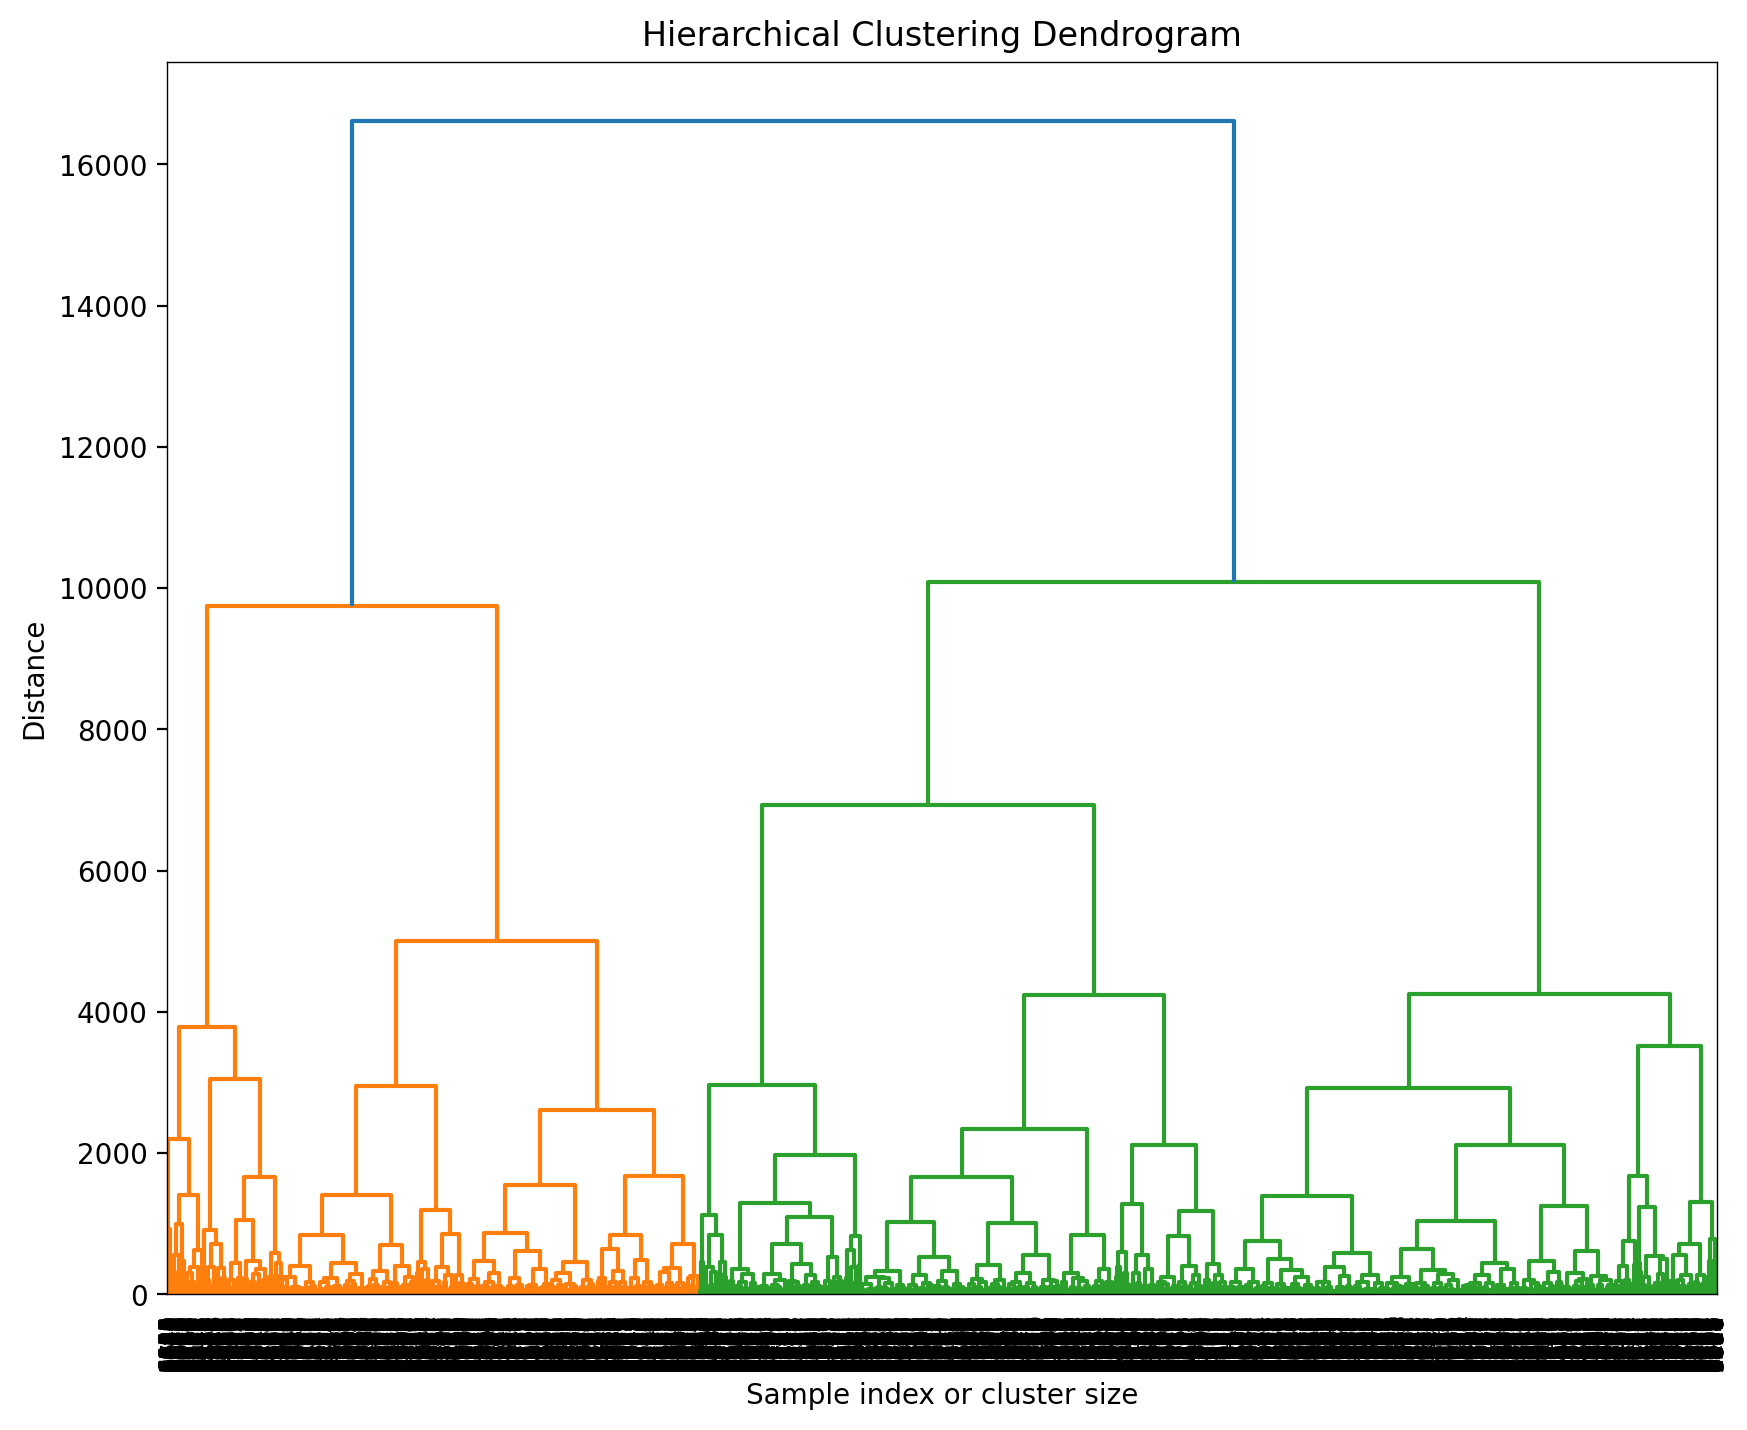

In [32]:
#Z = linkage(X, 'ward')
#row_linkage
#col_linkage

# 3. Plot the dendrogram
plt.figure(figsize=(10, 8))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index or cluster size')
plt.ylabel('Distance')

dendrogram(
    row_linkage,
    leaf_rotation=90.,  # Rotates the x-axis labels
    leaf_font_size=8.,  # Adjusts the font size for the labels
)

plt.show()

In [33]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
def calculate_cosine_within_cluster_similarity(data_matrix, labels):
    """
    Calculates the average within-cluster cosine similarity.
    Similarity is calculated between each point and its cluster centroid.
    """
    unique_labels = np.unique(labels)
    within_similarities = []

    for label in unique_labels:
        cluster_points = data_matrix[labels == label]
        if cluster_points.shape[0] > 1:
            centroid = cluster_points.mean(axis=0)
            centroid = centroid.reshape(1, -1) # Reshape for cosine_similarity
            sim = cosine_similarity(cluster_points, centroid)
            within_similarities.append(np.mean(sim))
        elif cluster_points.shape[0] == 1:
            # A single-point cluster has perfect similarity to itself
            within_similarities.append(1.0)

    if len(within_similarities) > 0:
        return np.mean(within_similarities)
    return 0.0

def calculate_cosine_between_cluster_similarity(data_matrix, labels):
    """
    Calculates the average between-cluster cosine similarity.
    Similarity is calculated between centroids of different clusters.
    """
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return 0.0 # Cannot calculate between-cluster similarity with less than 2 clusters

    cluster_centroids = {}
    for label in unique_labels:
        cluster_points = data_matrix[labels == label]
        cluster_centroids[label] = cluster_points.mean(axis=0)

    between_similarities = []
    # Iterate through unique pairs of clusters
    for i in range(len(unique_labels)):
        for j in range(i + 1, len(unique_labels)):
            label1 = unique_labels[i]
            label2 = unique_labels[j]

            centroid1 = cluster_centroids[label1].reshape(1, -1)
            centroid2 = cluster_centroids[label2].reshape(1, -1)

            sim = cosine_similarity(centroid1, centroid2)[0][0]
            between_similarities.append(sim)

    if len(between_similarities) > 0:
        return np.mean(between_similarities)
    return 0.0

In [41]:
Z = row_linkage
df = reordered_matrix

In [20]:

results = []
for n_clusters in range(2, 25):
    # Get cluster labels for the current number of clusters
    labels = fcluster(Z, n_clusters, criterion='maxclust')

    # Calculate similarities
    within_sim = calculate_cosine_within_cluster_similarity(df.values, labels)
    between_sim = calculate_cosine_between_cluster_similarity(df3.values, labels)

    results.append({
        'n_clusters': n_clusters,
        'within_cluster_similarity': within_sim,
        'between_cluster_similarity': between_sim
    })

# Convert results to a DataFrame for easier analysis and display
results_df = pd.DataFrame(results)
display(results_df.head())

,n_clusters,within_cluster_similarity,between_cluster_similarity
0,2,0.775867,0.594910
1,3,0.775239,0.660396
2,4,0.777620,0.571357
3,5,0.779294,0.445100
4,6,0.778729,0.511675


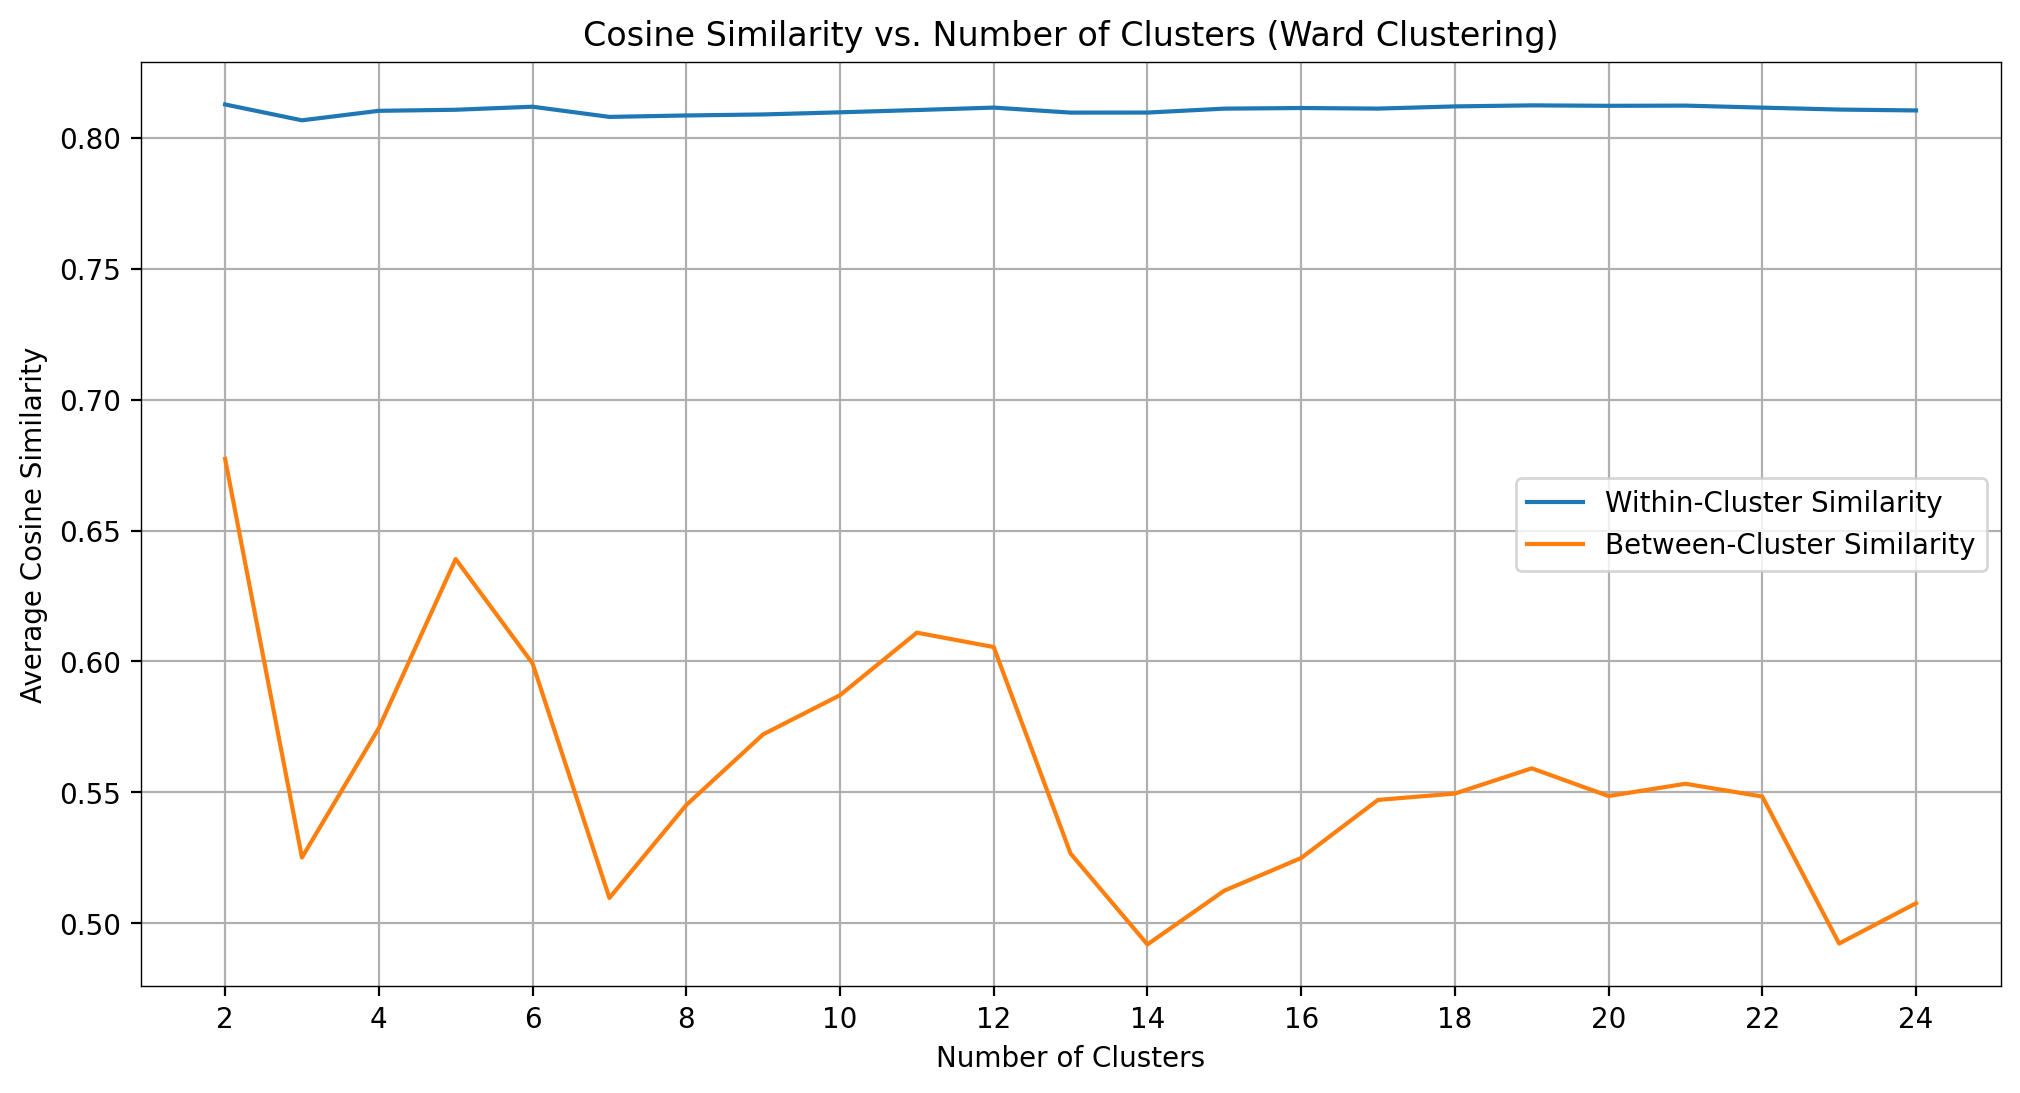

In [25]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='n_clusters', y='within_cluster_similarity', data=results_df, label='Within-Cluster Similarity')
sns.lineplot(x='n_clusters', y='between_cluster_similarity', data=results_df, label='Between-Cluster Similarity')
plt.title('Cosine Similarity vs. Number of Clusters (Ward Clustering)')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Cosine Similarity')
plt.xticks(range(2, 25, 2))
plt.grid(True)
plt.legend()
plt.show()

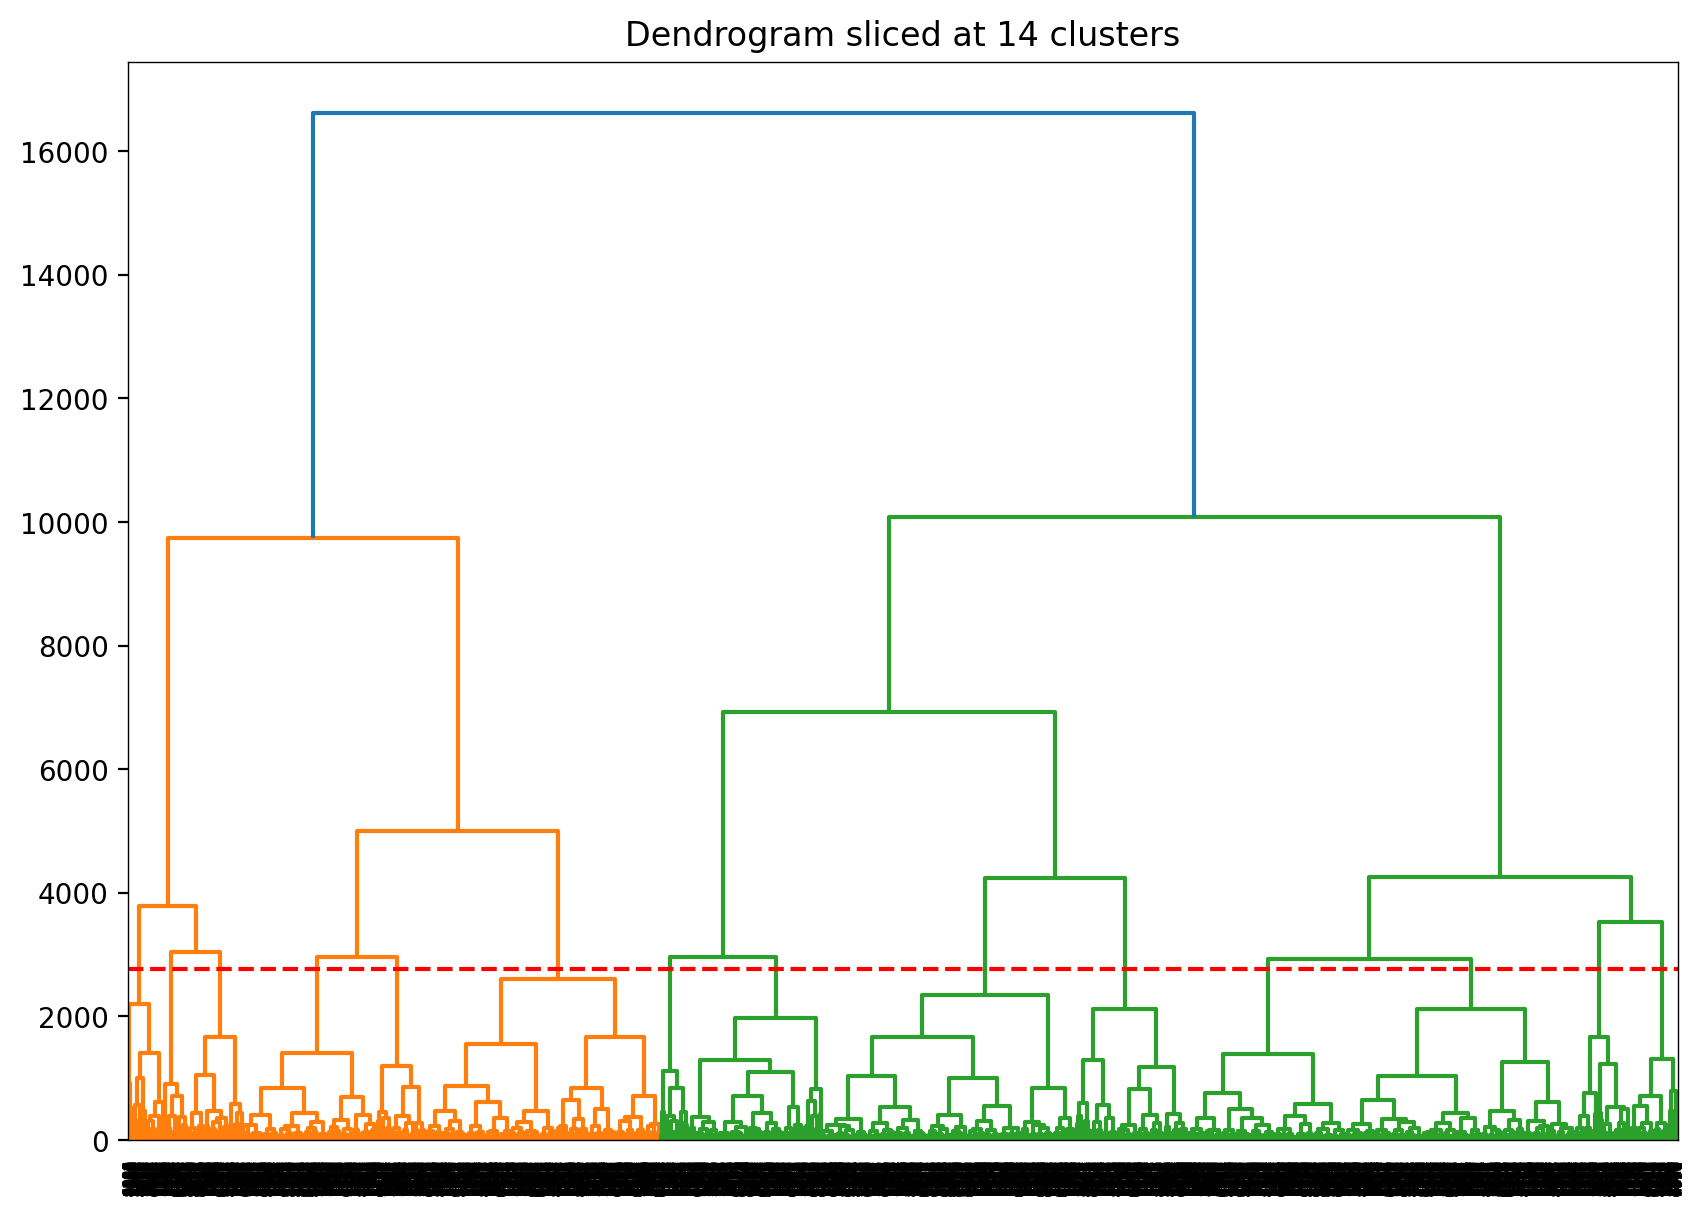

In [22]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Assuming Z is your linkage matrix and k is the number of clusters
Z = row_linkage
k = 14

# 1. Calculate the height threshold for k clusters
# The (n-k)th merge distance in Z[:, 2] determines the split
height = (Z[-(k), 2] + Z[-(k-1), 2]) / 2

# 2. Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z)

# 3. Add the horizontal slice line
plt.axhline(y=height, color='r', linestyle='--')
plt.title(f'Dendrogram sliced at {k} clusters')
plt.savefig('/home/wenyuantong/Desktop/figures/dendrogram_50-100_14clusters.png')
plt.show()

In [23]:
reordered_matrix.to_csv("/home/wenyuantong/Desktop/data/arabi_cross/50_100_Ward_reordered.csv", index=True)

In [24]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

In [25]:
df = df_numbered_indices

In [ ]:
#GMM

gmm_results = []
max_n_clusters = 25

for n_components in range(2, max_n_clusters):
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(df) # Fit GMM to the DataFrame
    labels = gmm.predict(df) # Predict cluster labels

    # Calculate metrics
    aic = gmm.aic(df)
    bic = gmm.bic(df)

    # Silhouette score requires at least 2 clusters and more than 1 sample per cluster
    silhouette = -1 # Default to -1 if calculation is not possible
    if len(np.unique(labels)) > 1 and df.shape[0] > len(np.unique(labels)):
        try:
            silhouette = silhouette_score(df, labels)
        except ValueError:
            silhouette = -1

    within_sim = calculate_cosine_within_cluster_similarity(df.values, labels)
    between_sim = calculate_cosine_between_cluster_similarity(df.values, labels)

    gmm_results.append({
        'n_clusters': n_components,
        'AIC': aic,
        'BIC': bic,
        'Silhouette_Score': silhouette,
        'within_cluster_similarity': within_sim,
        'between_cluster_similarity': between_sim
    })

gmm_results_df = pd.DataFrame(gmm_results)
display(gmm_results_df.head())


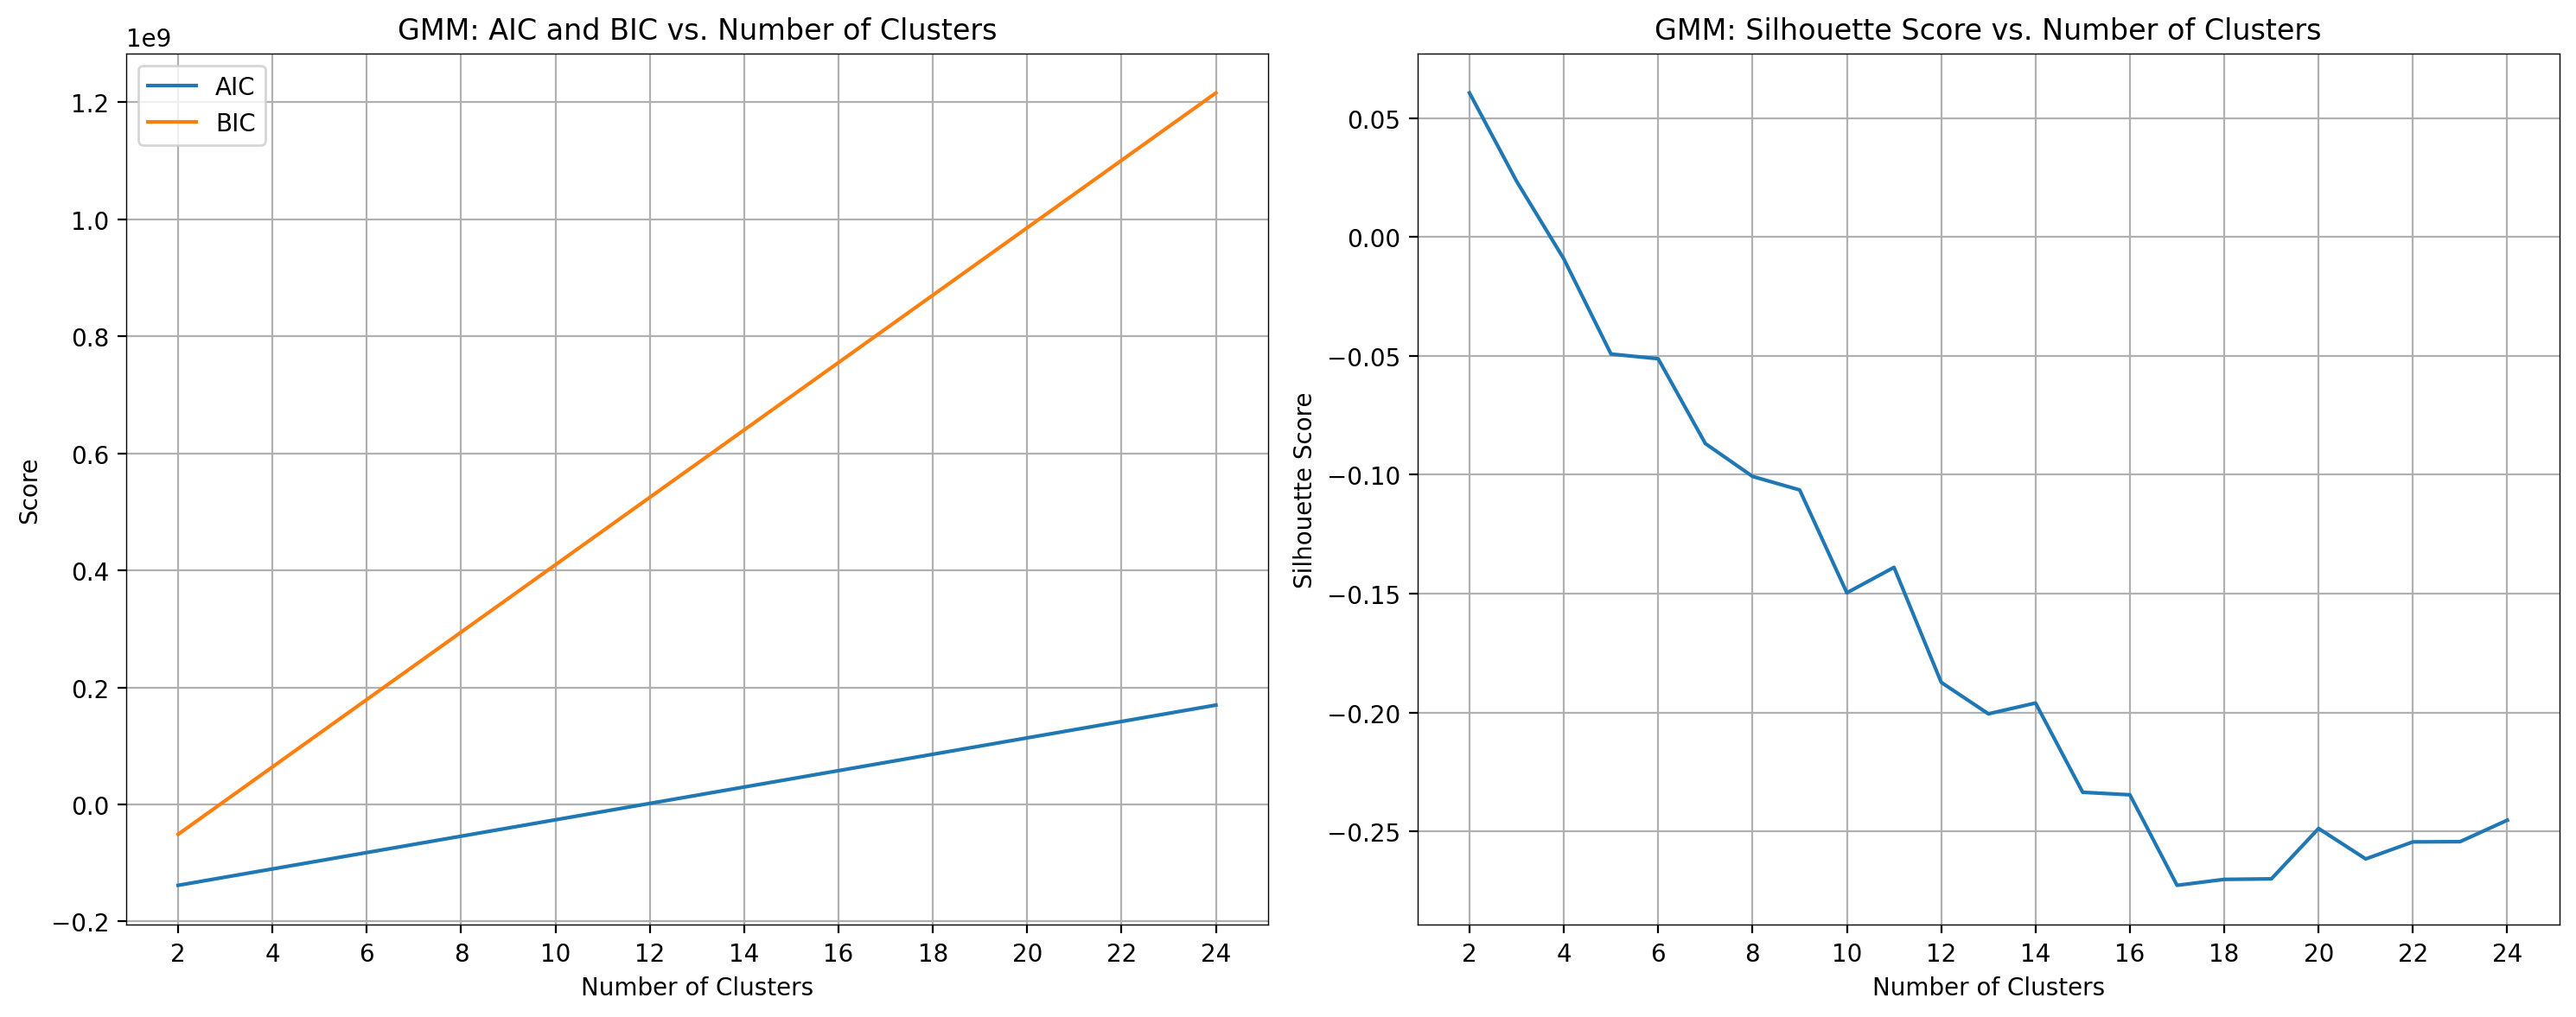

In [31]:
plt.figure(figsize=(15, 6))

# Plot AIC and BIC
plt.subplot(1, 2, 1)
sns.lineplot(x='n_clusters', y='AIC', data=gmm_results_df, label='AIC')
sns.lineplot(x='n_clusters', y='BIC', data=gmm_results_df, label='BIC')
plt.title('GMM: AIC and BIC vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.xticks(range(2, max_n_clusters, 2))
plt.grid(True)
plt.legend()

# Plot Silhouette Score
plt.subplot(1, 2, 2)
sns.lineplot(x='n_clusters', y='Silhouette_Score', data=gmm_results_df)
plt.title('GMM: Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, max_n_clusters, 2))
plt.grid(True)

plt.tight_layout()
plt.show()

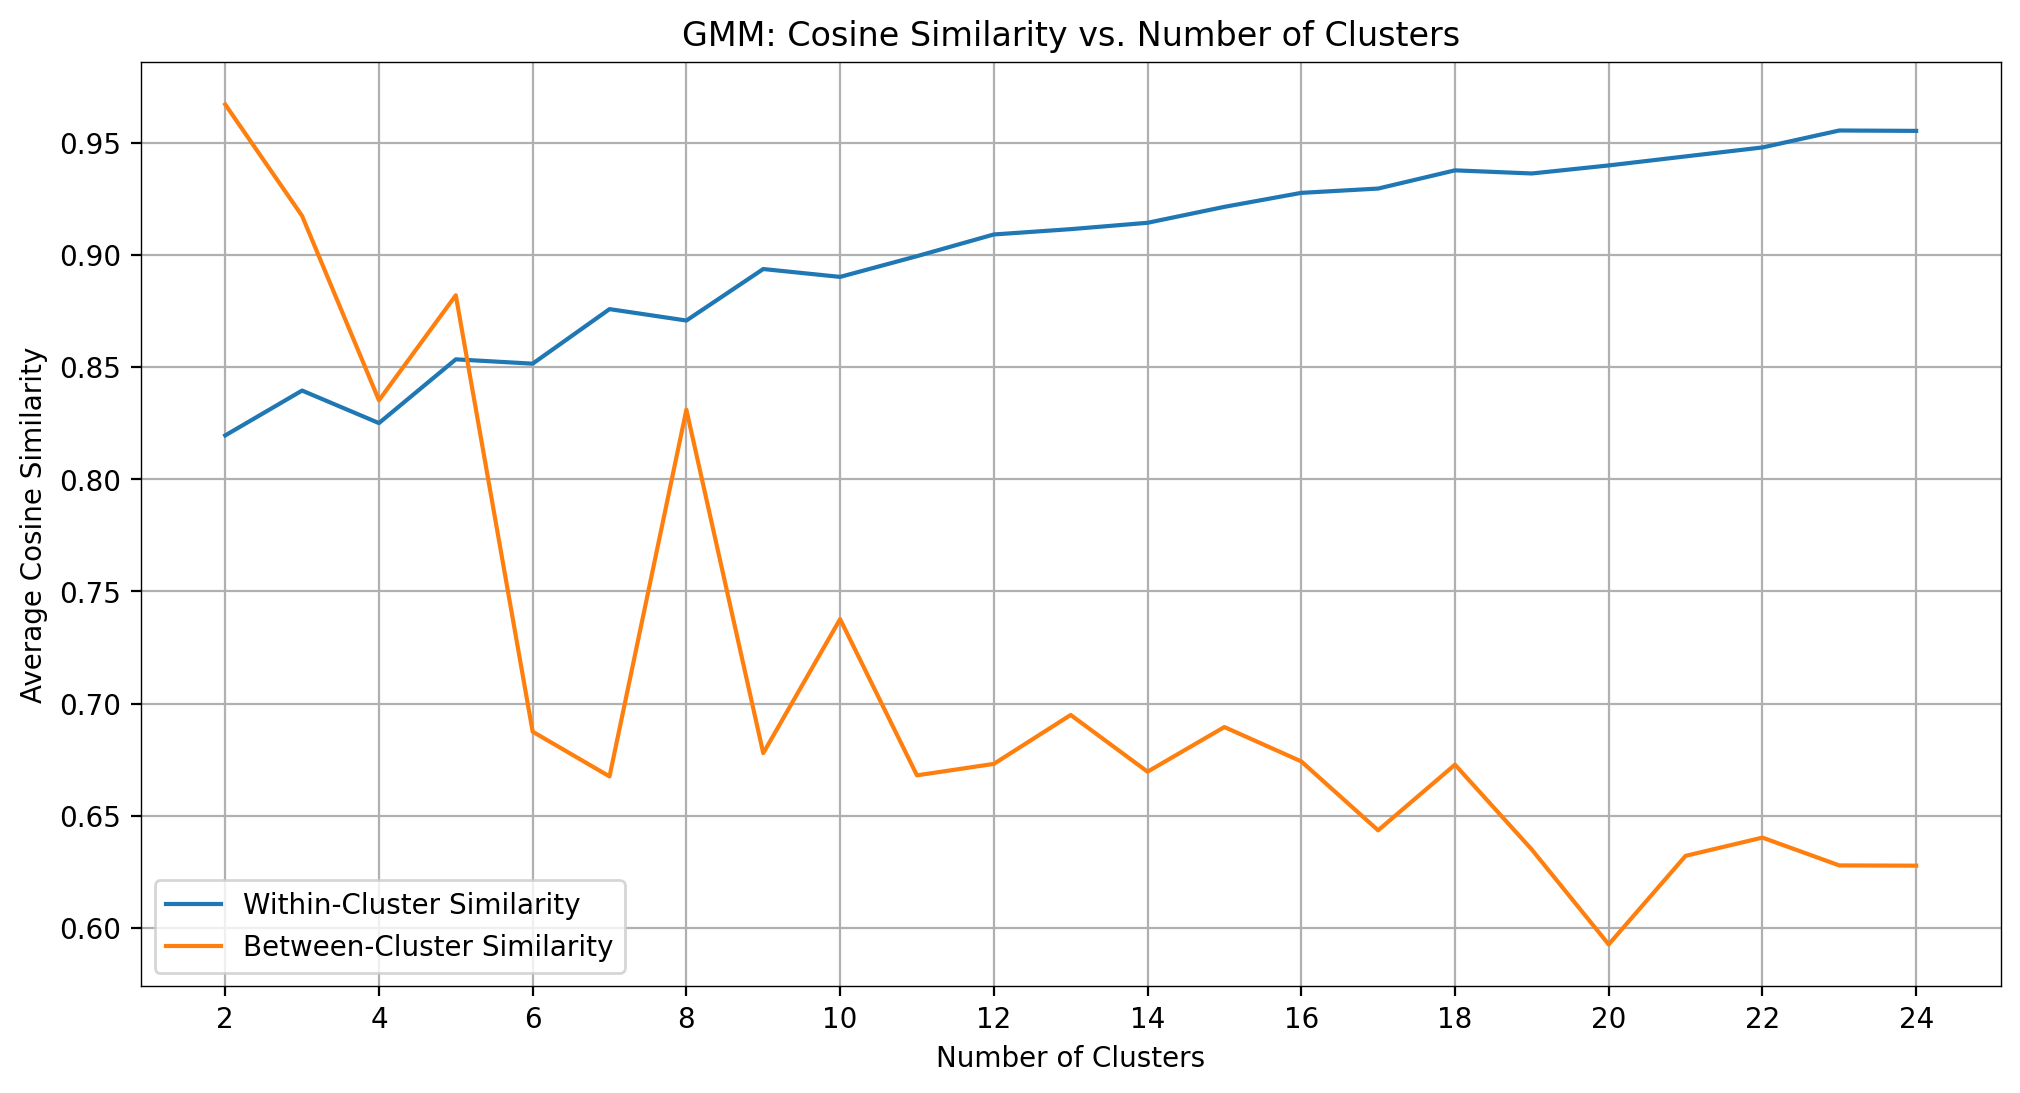

In [32]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='n_clusters', y='within_cluster_similarity', data=gmm_results_df, label='Within-Cluster Similarity')
sns.lineplot(x='n_clusters', y='between_cluster_similarity', data=gmm_results_df, label='Between-Cluster Similarity')
plt.title('GMM: Cosine Similarity vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Cosine Similarity')
plt.xticks(range(2, max_n_clusters, 2))
plt.grid(True)
plt.legend()
plt.show()

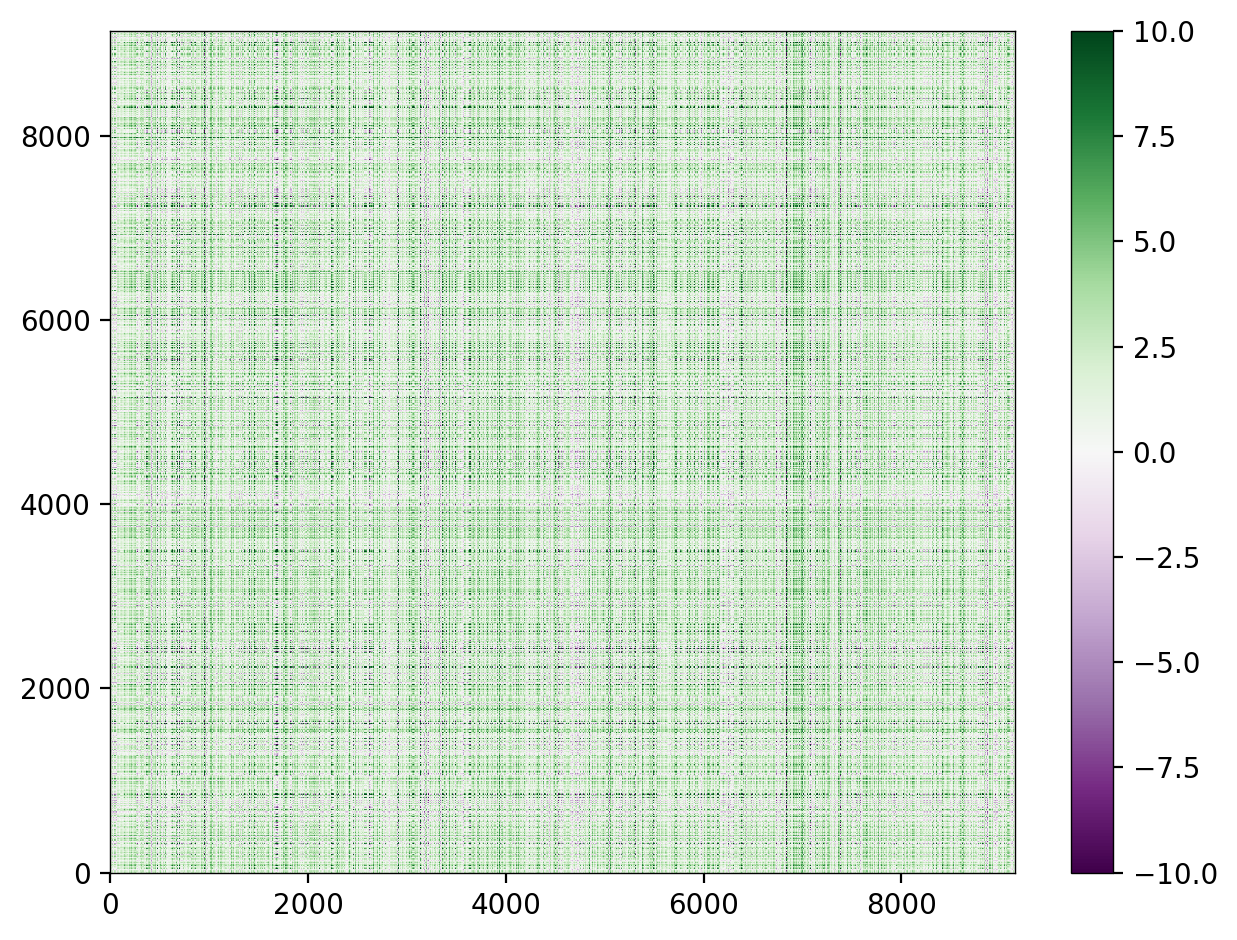

In [13]:
# test-drive simple representation - 
if mode == 'calvados':
    plt.imshow(reordered_matrix, vmin=-25, vmax=25,cmap='PRGn',interpolation='None', aspect='auto', origin='lower')
    plt.colorbar()
    plt.tight_layout()
elif mode == 'mpipi':
    plt.imshow(df_numbered_indices.values, vmin=-10, vmax=10,cmap='PRGn',interpolation='None', aspect='auto', origin='lower')
    plt.colorbar()
    #plt.show()
    plt.tight_layout()
    plt.savefig(f'/home/wenyuantong/Desktop/figures/all_50-100_{mode}.pdf')

In [14]:
for cluster_id in sorted(clustered_names_df3['spectral_cluster_label'].unique()):
    # Filter names for the current cluster
    names_in_cluster = clustered_names_df3[clustered_names_df3['spectral_cluster_label'] == cluster_id]['original_name'].tolist()

    # Remove whitespace from each name and join with a comma
    processed_names = [name.replace(' ', '') for name in names_in_cluster]
    output_line = ','.join(processed_names)

    # Define the filename for the current cluster
    filename = f'/home/wenyuantong/Desktop/data/50-100_clusters_panther/cluster_{cluster_id}_names.txt'

    # Write the processed names to the file
    with open(filename, 'w') as f:
        f.write(output_line)

    print(f"Names for Cluster {cluster_id} saved to {filename}")

ERROR! Session/line number was not unique in

NameError: name 'clustered_names_df3' is not defined

 database. History logging moved to new session 100


NameError: name 'row_linkage' is not defined

In [34]:
def calculate_average_pairwise_cosine_within_cluster_similarity(data_matrix, labels):
    """
    Calculates the average pairwise within-cluster cosine similarity.
    Similarity is calculated between all unique pairs of points within each cluster.
    """
    unique_labels = np.unique(labels)
    within_similarities = []

    for label in unique_labels:
        cluster_points = data_matrix[labels == label]
        N = cluster_points.shape[0]

        if N > 1:
            # Calculate pairwise cosine similarity for all points within the cluster
            # The resulting matrix will have 1s on the diagonal (self-similarity)
            pairwise_sim_matrix = cosine_similarity(cluster_points)

            # To get the average pairwise similarity excluding self-similarity:
            # Sum all similarities, subtract N (for the diagonal 1s), then divide by N * (N - 1)
            # (N*(N-1) is the number of unique pairs in both directions)
            sum_of_all_similarities = pairwise_sim_matrix.sum()
            avg_pairwise_sim = (sum_of_all_similarities - N) / (N * (N - 1))
            within_similarities.append(avg_pairwise_sim)
        elif N == 1:
            # A single-point cluster is considered perfectly cohesive internally
            within_similarities.append(1.0)

    if len(within_similarities) > 0:
        return np.mean(within_similarities)
    return 0.0

In [46]:
# Perform Ward hierarchical clustering to get the linkage matrix (Z is already defined from previous run)
# Z = linkage(df, method='ward')
Z = row_linkage

results_pairwise = []
for n_clusters in range(2, 25):
    # Get cluster labels for the current number of clusters
    labels = fcluster(Z, n_clusters, criterion='maxclust')

    # Calculate similarities using the new pairwise function
    within_sim_pairwise = calculate_average_pairwise_cosine_within_cluster_similarity(df.values, labels)
    between_sim = calculate_cosine_between_cluster_similarity(df3.values, labels) # Between-cluster remains centroid-based

    results_pairwise.append({
        'n_clusters': n_clusters,
        'within_cluster_similarity': within_sim_pairwise,
        'between_cluster_similarity': between_sim
    })

# Convert results to a DataFrame for easier analysis and display
results_df_pairwise = pd.DataFrame(results_pairwise)
display(results_df_pairwise.head())

,n_clusters,within_cluster_similarity,between_cluster_similarity
0,2,0.609143,0.594910
1,3,0.608342,0.660396
2,4,0.611436,0.571357
3,5,0.613992,0.445100
4,6,0.613188,0.511675


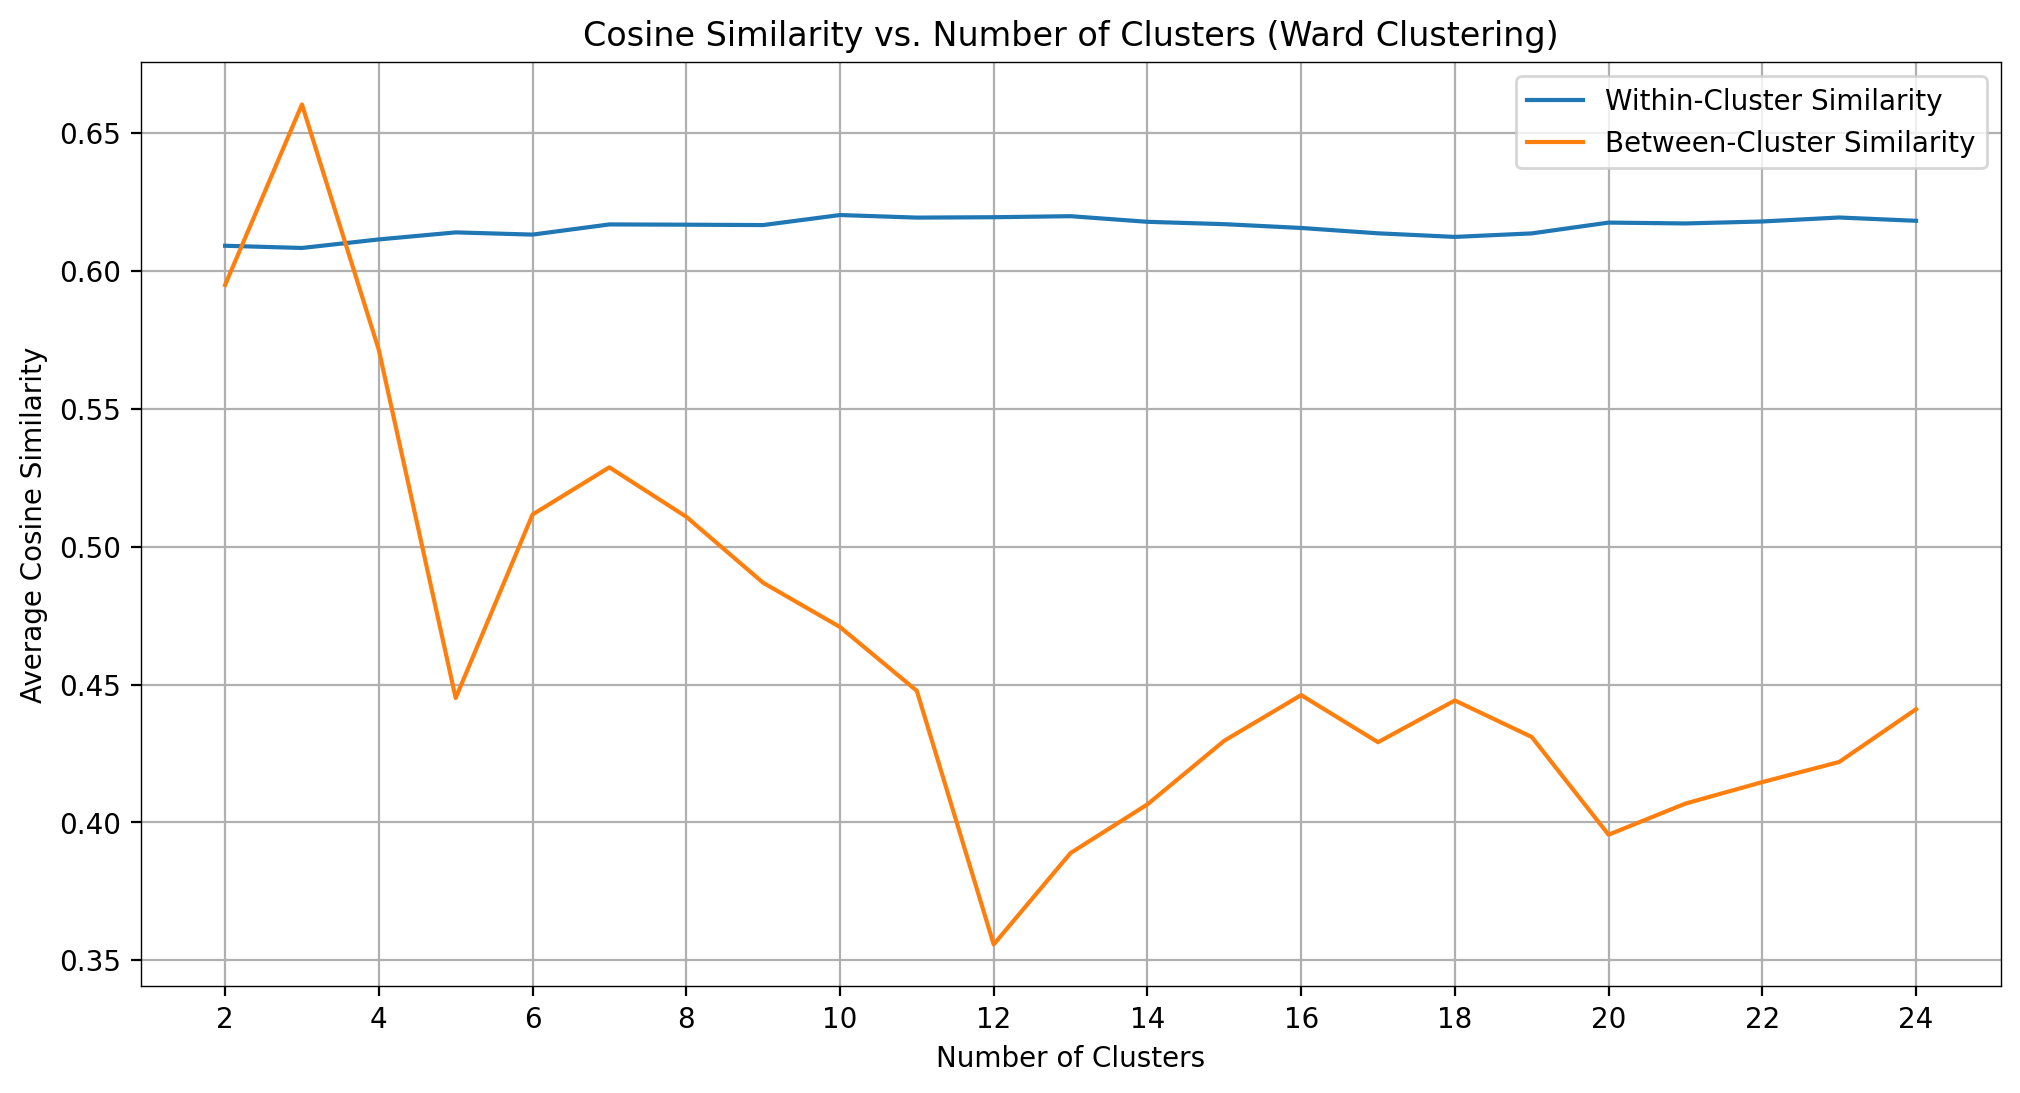

In [47]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='n_clusters', y='within_cluster_similarity', data=results_df_pairwise, label='Within-Cluster Similarity')
sns.lineplot(x='n_clusters', y='between_cluster_similarity', data=results_df_pairwise, label='Between-Cluster Similarity')
plt.title('Cosine Similarity vs. Number of Clusters (Ward Clustering)')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Cosine Similarity')
plt.xticks(range(2, 25, 2))
plt.grid(True)
plt.legend()
plt.show()